# Part II - Exploratory data analysis

This notebook describes demand and inventory behaviour **without selecting a model or policy**. Operational decisions are deferred to Part III, where the same pre-holdout information set is used to classify SKU classes and choose the intervention scope.

## Analysis boundary

Development EDA ends on 2025-09-30. The final 92 calendar days are shown only as a locked evaluation partition count; their demand, sales and inventory outcomes are not used in the charts or summary statistics below.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_PATH = Path('../data/processed/inventory_processed.csv')
CONFIG_PATH = Path('../src/backend/config/config.json')
with CONFIG_PATH.open(encoding='utf-8') as f:
    config = json.load(f)

TRAIN_START = pd.Timestamp(config['data']['train_start'])
VALIDATION_START = pd.Timestamp(config['data']['validation_start'])
VALIDATION_END = pd.Timestamp(config['data']['validation_end'])
FINAL_TEST_START = pd.Timestamp(config['data']['final_test_start'])
assert TRAIN_START <= VALIDATION_START <= VALIDATION_END < FINAL_TEST_START
df_inventory = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values(['sku_id', 'date'])
assert df_inventory['date'].min() == TRAIN_START
df_development = df_inventory.loc[df_inventory['date'] < FINAL_TEST_START].copy()
df_final_holdout = df_inventory.loc[df_inventory['date'] >= FINAL_TEST_START, ['sku_id', 'date']].copy()

In [2]:
partition_summary = pd.DataFrame([
    {'partition': 'development / selection data', 'start': df_development['date'].min().date(),
     'end': df_development['date'].max().date(), 'rows': len(df_development), 'purpose': 'EDA, class/model/policy selection'},
    {'partition': 'final holdout (locked)', 'start': df_final_holdout['date'].min().date(),
     'end': df_final_holdout['date'].max().date(), 'rows': len(df_final_holdout), 'purpose': 'locked retrospective evaluation'}
])
partition_summary

,partition,start,end,rows,purpose
0,development / selection data,2024-01-01,2025-09-30,95850,"EDA, class/model/policy selection"
1,final holdout (locked),2025-10-01,2025-12-31,13800,locked retrospective evaluation


## Portfolio and demand overview

In [3]:
portfolio_summary = pd.DataFrame({
    'metric': ['SKUs', 'categories', 'development days', 'total demand', 'realized sales', 'lost demand', 'development fill rate'],
    'value': [
        df_development['sku_id'].nunique(),
        df_development['category'].nunique(),
        df_development['date'].nunique(),
        df_development['demand'].sum(),
        df_development['sales_quantity'].sum(),
        (df_development['demand'] - df_development['sales_quantity']).sum(),
        df_development['sales_quantity'].sum() / df_development['demand'].sum(),
    ]
})
portfolio_summary

,metric,value
0,SKUs,150.000
1,categories,10.000
2,development days,639.000
3,total demand,"1,477,128.000"
4,realized sales,"1,410,745.000"
5,lost demand,"66,383.000"
6,development fill rate,0.955


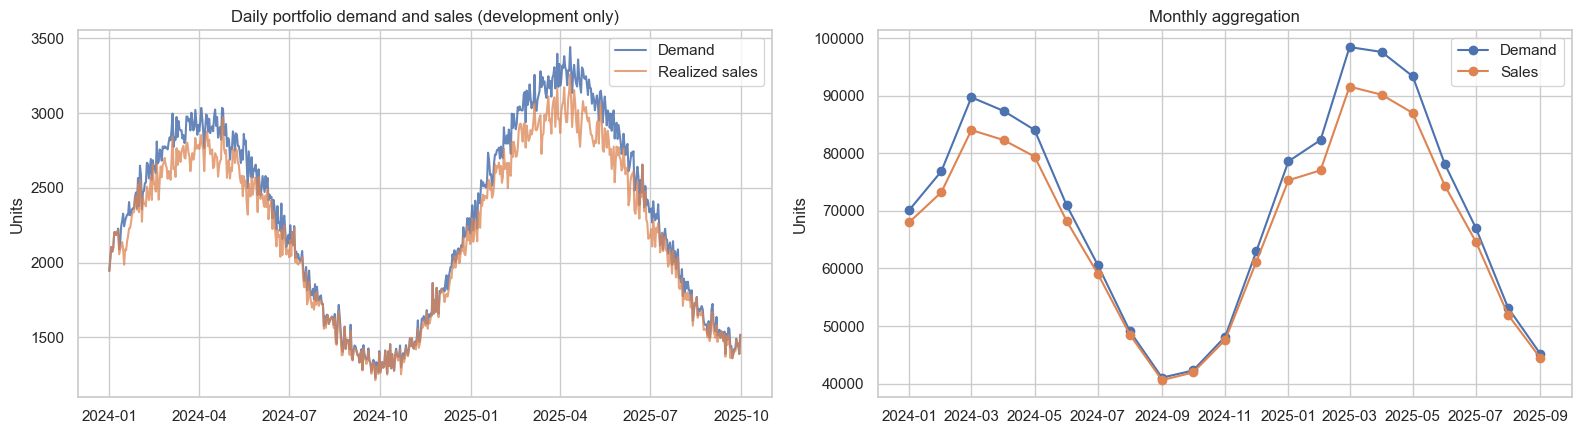

In [4]:
daily_demand = df_development.groupby('date', as_index=False).agg(
    demand=('demand', 'sum'), sales=('sales_quantity', 'sum')
)
monthly_demand = (daily_demand.set_index('date')[['demand', 'sales']]
                  .resample('MS').sum().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
axes[0].plot(daily_demand['date'], daily_demand['demand'], label='Demand', alpha=.85)
axes[0].plot(daily_demand['date'], daily_demand['sales'], label='Realized sales', alpha=.75)
axes[0].set(title='Daily portfolio demand and sales (development only)', xlabel='', ylabel='Units')
axes[0].legend()
axes[1].plot(monthly_demand['date'], monthly_demand['demand'], marker='o', label='Demand')
axes[1].plot(monthly_demand['date'], monthly_demand['sales'], marker='o', label='Sales')
axes[1].set(title='Monthly aggregation', xlabel='', ylabel='Units')
axes[1].legend()
plt.tight_layout()

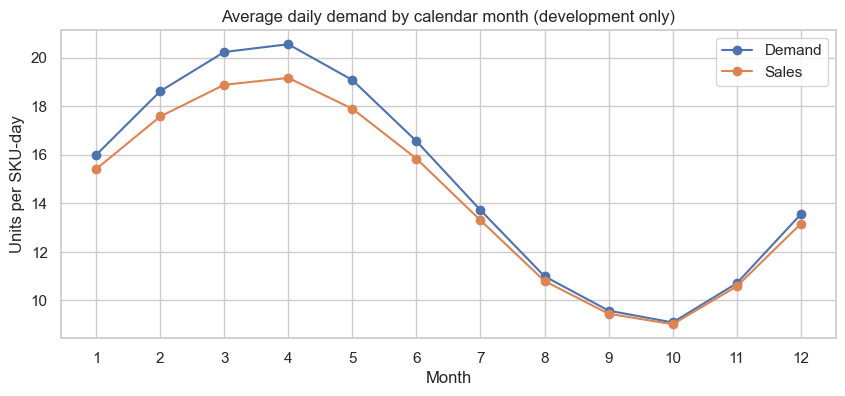

In [5]:
seasonality = df_development.assign(month=df_development['date'].dt.month).groupby('month').agg(
    avg_daily_demand=('demand', 'mean'), avg_daily_sales=('sales_quantity', 'mean')
).reset_index()

plt.figure(figsize=(10, 4))
plt.plot(seasonality['month'], seasonality['avg_daily_demand'], marker='o', label='Demand')
plt.plot(seasonality['month'], seasonality['avg_daily_sales'], marker='o', label='Sales')
plt.xticks(range(1, 13))
plt.title('Average daily demand by calendar month (development only)')
plt.xlabel('Month')
plt.ylabel('Units per SKU-day')
plt.legend()
plt.show()

The visible month pattern supports comparing a seasonal baseline in Part IV. It is not, by itself, evidence that a seasonal model will win; model choice is made on rolling validation WAPE.

## Inventory-operation diagnostics

The following metrics use the same development period. `fill_rate` is demand-weighted to avoid a low-volume SKU being treated as equally important as a high-volume SKU. DOI is an operational proxy: average end-of-day inventory divided by average daily demand.

In [6]:
sku_operations = df_development.groupby('sku_id').agg(
    category=('category', 'first'),
    total_demand=('demand', 'sum'),
    total_sales=('sales_quantity', 'sum'),
    avg_inventory=('inventory_level', 'mean'),
    avg_daily_demand=('demand', 'mean'),
    demand_std=('demand', 'std'),
    lead_time=('lead_time', 'median')
).reset_index()
sku_operations['lost_demand'] = sku_operations['total_demand'] - sku_operations['total_sales']
sku_operations['fill_rate'] = sku_operations['total_sales'] / sku_operations['total_demand']
sku_operations['doi'] = sku_operations['avg_inventory'] / sku_operations['avg_daily_demand'].replace(0, np.nan)
sku_operations['demand_cv'] = sku_operations['demand_std'] / sku_operations['avg_daily_demand'].replace(0, np.nan)
sku_operations[['total_demand', 'lost_demand', 'fill_rate', 'doi', 'demand_cv']].describe(percentiles=[.1, .5, .9])

,total_demand,lost_demand,fill_rate,doi,demand_cv
count,150.000,150.000,150.000,150.000,150.000
mean,"9,847.520",442.553,0.969,28.715,0.448
std,"4,447.068","1,033.787",0.066,18.823,0.049
min,"3,539.000",0.000,0.629,5.037,0.378
10%,"4,314.900",0.000,0.883,10.055,0.396
50%,"10,019.500",0.000,1.000,23.255,0.431
90%,"17,811.100","1,526.800",1.000,55.663,0.526
max,"18,463.000","6,618.000",1.000,89.982,0.571


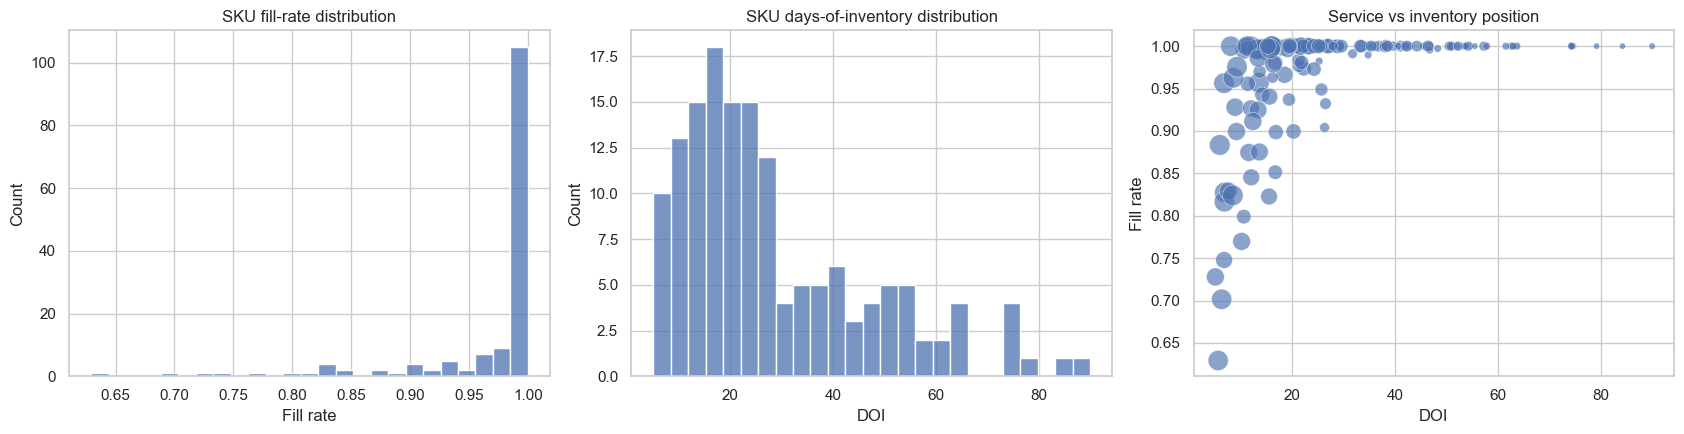

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(sku_operations['fill_rate'], bins=25, ax=axes[0])
axes[0].set(title='SKU fill-rate distribution', xlabel='Fill rate')
sns.histplot(sku_operations['doi'].dropna(), bins=25, ax=axes[1])
axes[1].set(title='SKU days-of-inventory distribution', xlabel='DOI')
sns.scatterplot(data=sku_operations, x='doi', y='fill_rate', size='total_demand', sizes=(20, 220), alpha=.65, ax=axes[2], legend=False)
axes[2].set(title='Service vs inventory position', xlabel='DOI', ylabel='Fill rate')
plt.tight_layout()

In [8]:
category_summary = df_development.groupby('category').agg(
    sku_count=('sku_id', 'nunique'), demand=('demand', 'sum'), sales=('sales_quantity', 'sum'),
    avg_eod_inventory=('inventory_level', 'mean')
).reset_index()
category_summary['fill_rate'] = category_summary['sales'] / category_summary['demand']
category_summary['lost_demand'] = category_summary['demand'] - category_summary['sales']
category_summary.sort_values('demand', ascending=False)

,category,sku_count,demand,sales,avg_eod_inventory,fill_rate,lost_demand
6,Phone Case,18,324905,298186,286.984,0.918,26719
0,Headphones,16,208632,198803,329.518,0.953,9829
5,Other Accessories,18,181901,177783,324.716,0.977,4118
4,Mouse,16,173630,169739,321.128,0.978,3891
7,Power Bank,12,173316,154616,269.110,0.892,18700
8,Smartphone,14,122103,120508,363.483,0.987,1595
9,Tablet,17,98320,97707,355.196,0.994,613
3,Monitor,20,86336,86182,353.437,0.998,154
1,Keyboard,11,79046,78282,388.366,0.990,764
2,Laptop,8,28939,28939,413.024,1.000,0


## Intermittency, stockout censoring and replenishment behaviour

Zero demand and censored sales affect how forecast error and ABC value should be interpreted. Lead-time and receipt behaviour also determine whether a one-day forecast is sufficient for policy calibration.

,metric,value
0,zero-demand SKU-days,432
1,SKUs with at least one zero-demand day,99
2,stockout-censored SKU-days,3003
3,receipt events,2674
4,lead-time range,3–14 days


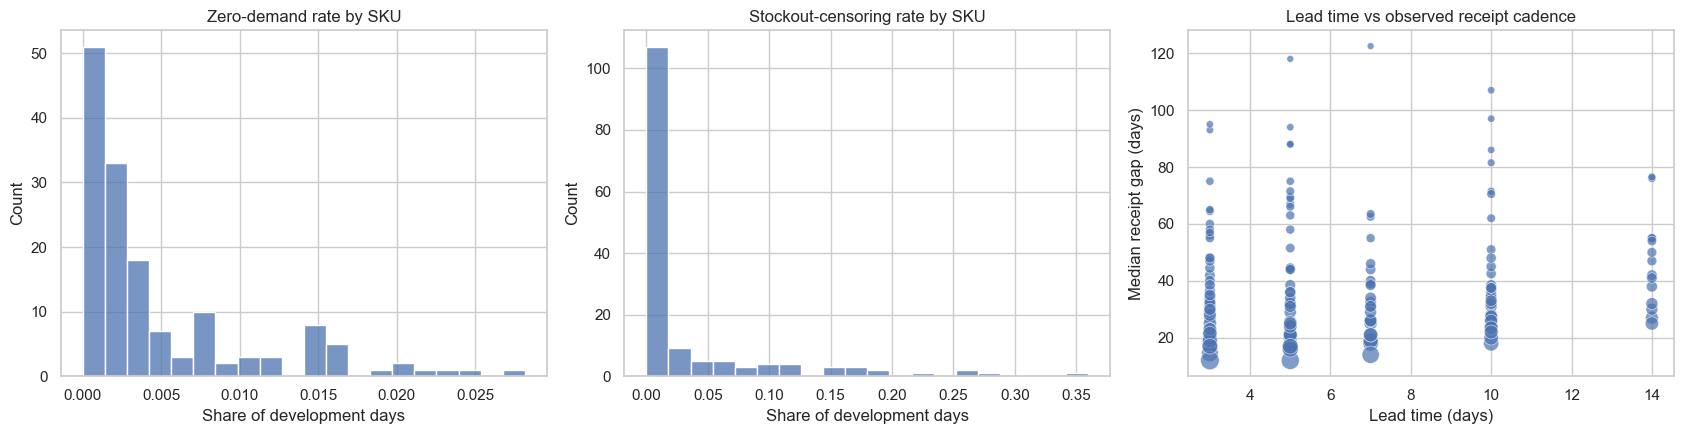

In [9]:
behavior = df_development.assign(
    zero_demand=df_development['demand'].eq(0),
    censored_sales=df_development['sales_quantity'].lt(df_development['demand']),
).groupby('sku_id').agg(
    zero_demand_rate=('zero_demand', 'mean'),
    stockout_censoring_rate=('censored_sales', 'mean'),
    nonzero_demand_days=('demand', lambda s: s.gt(0).sum()),
).reset_index()
behavior['average_demand_interval'] = df_development['date'].nunique() / behavior['nonzero_demand_days']

receipts = df_development.loc[df_development['order_received'] > 0, ['sku_id', 'date', 'order_received']].copy()
receipts['days_since_previous_receipt'] = receipts.groupby('sku_id')['date'].diff().dt.days
replenishment = df_development.groupby('sku_id').agg(lead_time=('lead_time', 'median')).reset_index()
replenishment = replenishment.merge(
    receipts.groupby('sku_id').agg(receipt_events=('date', 'count'), median_receipt_gap=('days_since_previous_receipt', 'median')).reset_index(),
    on='sku_id', how='left', validate='one_to_one'
)
eda_risk_summary = pd.DataFrame({
    'metric': ['zero-demand SKU-days', 'SKUs with at least one zero-demand day', 'stockout-censored SKU-days', 'receipt events', 'lead-time range'],
    'value': [int((df_development['demand'] == 0).sum()), int((behavior['zero_demand_rate'] > 0).sum()),
              int((df_development['sales_quantity'] < df_development['demand']).sum()), len(receipts),
              f"{int(replenishment['lead_time'].min())}–{int(replenishment['lead_time'].max())} days"]
})
display(eda_risk_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(behavior['zero_demand_rate'], bins=20, ax=axes[0])
axes[0].set(title='Zero-demand rate by SKU', xlabel='Share of development days')
sns.histplot(behavior['stockout_censoring_rate'], bins=20, ax=axes[1])
axes[1].set(title='Stockout-censoring rate by SKU', xlabel='Share of development days')
sns.scatterplot(data=replenishment, x='lead_time', y='median_receipt_gap', size='receipt_events', sizes=(25, 180), alpha=.7, ax=axes[2], legend=False)
axes[2].set(title='Lead time vs observed receipt cadence', xlabel='Lead time (days)', ylabel='Median receipt gap (days)')
plt.tight_layout()

### Key findings and limits

- Actual demand, rather than fulfilled sales, must drive ABC because stockout days censor sales.
- Zero-demand behaviour is measured explicitly before interpreting CV/forecastability; no intermittent-demand model is selected unless the observed rates justify it.
- Lead times span multiple days, so Part V must calibrate safety stock from cumulative lead-time residuals rather than label daily RMSE as a lead-time error.
- This EDA uses only development/selection data. The locked evaluation outcomes remain excluded from downstream decisions.

### Handoff

Part III converts the operational evidence into ABC/XYZ classes and a transparent optimization scope using pre-evaluation data only. Part IV compares forecasts on validation folds; Part V calibrates policy from cumulative validation residuals and simulates both policies on the locked evaluation window.